In [1]:
# ============================================================
# 1. Imports
# ============================================================

import os
import re
import json
import math
import time
import shutil
import hashlib
import platform
import datetime as dt
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gensim.models import FastText

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
)
from sklearn.exceptions import ConvergenceWarning

import gensim
import joblib
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

print("Python:", platform.python_version())
print("Platform:", platform.platform())
print("Gensim:", gensim.__version__)


Python: 3.12.13
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
Gensim: 4.4.0


In [2]:
# ============================================================
# 2. Central configuration
# ============================================================

CONFIG = {
    # Experiment identity
    "project_name": "extremism_text_classification",
    "technique_name": "FASTTEXT-EMB_LOG-REG",
    "model_family": "logistic_regression",
    "feature_family": "fasttext_document_embeddings",
    "dataset_version": "extremism_dataset_clean_v1",
    "split_version": "split_v1",
    "random_seed": 30,

    # Paths
    # Leave these as None to auto-discover the files under /kaggle/input or /kaggle/working.
    # If auto-discovery fails, paste exact paths from Kaggle's file browser.
    "processed_dataset_path": None,
    "split_assignments_path": None,
    "dataset_manifest_path": None,

    # Required columns from 00_create_dataset_and_splits.ipynb
    "id_col": "row_id",
    "text_col": "text",
    "label_col": "label",
    "split_col": "split",
    "positive_label": 1,

    # Output
    "output_root": "/kaggle/working/experiments",
    "overwrite_output_dir": True,

    # Tokenization for training FastText and pooling token vectors.
    # This keeps social-media tokens such as hashtags/mentions/URLs as explicit tokens when present.
    "tokenization": {
        "lowercase": True,
        "pattern": r"(?u)https?://\S+|#\w+|@\w+|\b\w+\b|[^\w\s]",
    },

    # Fixed FastText settings.
    # FastText is trained on the train split only. It uses subword character n-grams, which can help with
    # noisy social-media spelling, rare terms, hashtags, and mild obfuscation.
    "fasttext": {
        "min_count": 1,
        "sg": 1,                  # 1 = skip-gram; good default for rare/social-media terms
        "epochs": 15,
        "min_n": 3,
        "max_n": 6,
        "negative": 10,
        "sample": 1e-3,
        "workers": 1,             # use 1 for reproducibility
    },

    # Ablation / tuning
    # This grid is validation-only. It keeps the same research protocol and comparable scale as earlier notebooks.
    # Total configs: 2 * 2 * 2 * 2 * 3 * 2 = 96.
    "ablation_grid": {
        "vector_size": [100, 200],
        "window": [3, 5],
        "pooling": ["mean", "idf_weighted_mean"],
        "normalize_embeddings": [False, True],
        "C": [0.3, 1.0, 3.0],
        "class_weight": [None, "balanced"],
    },

    # Logistic regression classifier settings
    "classifier": {
        "solver": "lbfgs",
        "max_iter": 5000,
        "tol": 1e-4,
        "random_state": 30,
    },

    # Thresholding
    # Recommended default: maximize validation positive-class F1.
    "threshold_strategy": "maximize_val_f1",
    "threshold_grid": {
        "start": 0.01,
        "stop": 0.99,
        "num": 99,
    },

    # Explainability
    # For embedding models, interpretability is approximate:
    # - Global: classifier direction over embedding dimensions + tokens scored by dot product with classifier direction.
    # - Local: token-level approximate contributions to the logistic-regression margin.
    "explainability": {
        "top_n_global": 100,
        "top_k_local_features": 15,
        "max_local_examples_total": 120,
        "max_vocab_tokens_to_score": 50000,
        "include_text_preview": False,
        "text_preview_chars": 240,
    },

    # Error analysis
    "error_analysis": {
        "examples_per_bucket": 25,
        "near_threshold_margin": 0.05,
        "include_text_preview": False,
        "text_preview_chars": 240,
    },
}

TECHNIQUE_NAME = CONFIG["technique_name"]
OUTPUT_DIR = Path(CONFIG["output_root"]) / TECHNIQUE_NAME

print("Technique:", TECHNIQUE_NAME)
print("Output directory:", OUTPUT_DIR)


Technique: FASTTEXT-EMB_LOG-REG
Output directory: /kaggle/working/experiments/FASTTEXT-EMB_LOG-REG


In [3]:
# ============================================================
# 3. Reproducibility and helper functions
# ============================================================

def set_global_seed(seed: int) -> None:
    import random
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

def make_json_safe(obj):
    """Convert numpy/scipy/path objects into JSON-serializable Python objects."""
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        if math.isnan(float(obj)):
            return None
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    try:
        if pd.isna(obj) and not isinstance(obj, (list, tuple, dict, np.ndarray)):
            return None
    except Exception:
        pass
    return obj

def save_json(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(make_json_safe(obj), f, indent=2)

def sha256_file(path: Path, n_chars: int = 16) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()[:n_chars]

def sha256_text(text: str, n_chars: int = 16) -> str:
    return hashlib.sha256(str(text).encode("utf-8")).hexdigest()[:n_chars]

def find_file_by_name(file_name: str, search_roots=None) -> Path:
    """Find a file under common Kaggle locations. Raises a clear error if not found."""
    if search_roots is None:
        search_roots = [Path("/kaggle/input"), Path("/kaggle/working"), Path(".")]

    matches = []
    for root in search_roots:
        if root.exists():
            matches.extend(root.rglob(file_name))

    matches = sorted(set(matches), key=lambda p: (len(str(p)), str(p)))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find {file_name}.\n"
            "Set the relevant CONFIG path manually in cell 2."
        )

    print(f"Found {file_name}:")
    for m in matches[:10]:
        print(" -", m)
    if len(matches) > 1:
        print(f"Using first match: {matches[0]}")
    return matches[0]

def initialize_output_dir(output_dir: Path, overwrite: bool = True) -> None:
    if output_dir.exists() and overwrite:
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    for subdir in [
        "model_artifacts",
        "plots",
        "interpretability",
        "error_analysis",
        "ablation",
    ]:
        (output_dir / subdir).mkdir(parents=True, exist_ok=True)

set_global_seed(CONFIG["random_seed"])
initialize_output_dir(OUTPUT_DIR, CONFIG["overwrite_output_dir"])

save_json(CONFIG, OUTPUT_DIR / "config.json")

print("Initialized output directory.")


Initialized output directory.


In [4]:
# ============================================================
# 4. Load processed dataset, split assignments, and manifest
# ============================================================

processed_dataset_path = (
    Path(CONFIG["processed_dataset_path"])
    if CONFIG["processed_dataset_path"] is not None
    else find_file_by_name("processed_dataset.csv")
)

split_assignments_path = (
    Path(CONFIG["split_assignments_path"])
    if CONFIG["split_assignments_path"] is not None
    else find_file_by_name("split_assignments.csv")
)

dataset_manifest_path = (
    Path(CONFIG["dataset_manifest_path"])
    if CONFIG["dataset_manifest_path"] is not None
    else find_file_by_name("dataset_manifest.json")
)

df = pd.read_csv(processed_dataset_path)
splits = pd.read_csv(split_assignments_path)

with open(dataset_manifest_path, "r") as f:
    dataset_manifest = json.load(f)

print("Processed dataset path:", processed_dataset_path)
print("Split assignments path:", split_assignments_path)
print("Dataset manifest path:", dataset_manifest_path)
print("Dataset shape:", df.shape)
print("Split shape:", splits.shape)

display(df.head())
display(splits.head())


Found processed_dataset.csv:
 - /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/processed_dataset.csv
Found split_assignments.csv:
 - /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/split_assignments.csv
Found dataset_manifest.json:
 - /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/dataset_manifest.json
Processed dataset path: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/processed_dataset.csv
Split assignments path: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/split_assignments.csv
Dataset manifest path: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/dataset_manifest.json
Dataset shape: (2999, 8)
Split shape: (2999, 4)


,row_id,original_index,text,label,raw_label,text_hash,char_len,word_len
0,ex_000000,0,sixth forms should burn to the ground,1,EXTREMIST,e0cc81a4d5f0f2b3,37,7
1,ex_000001,1,whatever should burn benders to the ground,1,EXTREMIST,906f97390ef91f64,42,7
2,ex_000002,2,factories should burn to the ground,1,EXTREMIST,50fe44bc8cf60d1c,35,6
3,ex_000003,3,halal factories should burn to the ground,1,EXTREMIST,4bedb3fea5ed5fbe,41,7
4,ex_000004,4,nhs should burn to the ground,1,EXTREMIST,f1a8b2543327a925,29,6


,row_id,label,text_hash,split
0,ex_000000,1,e0cc81a4d5f0f2b3,test
1,ex_000001,1,906f97390ef91f64,train
2,ex_000002,1,50fe44bc8cf60d1c,validation
3,ex_000003,1,4bedb3fea5ed5fbe,validation
4,ex_000004,1,f1a8b2543327a925,validation


In [5]:
# ============================================================
# 5. Validate schema and apply canonical split
# ============================================================

id_col = CONFIG["id_col"]
text_col = CONFIG["text_col"]
label_col = CONFIG["label_col"]
split_col = CONFIG["split_col"]

required_df_cols = {id_col, text_col, label_col}
required_split_cols = {id_col, split_col}

missing_df_cols = required_df_cols - set(df.columns)
missing_split_cols = required_split_cols - set(splits.columns)

if missing_df_cols:
    raise ValueError(f"Processed dataset is missing required columns: {missing_df_cols}")
if missing_split_cols:
    raise ValueError(f"Split assignment file is missing required columns: {missing_split_cols}")

# Merge split assignments onto the processed dataset.
# Validate that every row has exactly one split.
merged = df.merge(splits[[id_col, split_col]], on=id_col, how="left", validate="one_to_one")

if merged[split_col].isna().any():
    missing = merged[merged[split_col].isna()][id_col].head().tolist()
    raise ValueError(f"Some dataset rows are missing split assignments. Example row_ids: {missing}")

allowed_splits = {"train", "validation", "test"}
observed_splits = set(merged[split_col].unique())
if not observed_splits.issubset(allowed_splits):
    raise ValueError(f"Unexpected split labels found: {observed_splits - allowed_splits}")

# Ensure text and labels have safe types.
merged[text_col] = merged[text_col].fillna("").astype(str)
merged[label_col] = merged[label_col].astype(int)

train_df = merged[merged[split_col] == "train"].reset_index(drop=True)
val_df = merged[merged[split_col] == "validation"].reset_index(drop=True)
test_df = merged[merged[split_col] == "test"].reset_index(drop=True)

print("Split sizes:")
print("train:", len(train_df))
print("validation:", len(val_df))
print("test:", len(test_df))

split_audit = (
    merged
    .groupby([split_col, label_col])
    .size()
    .reset_index(name="count")
)
split_audit["rate_within_split"] = split_audit.groupby(split_col)["count"].transform(lambda s: s / s.sum())
display(split_audit)

split_audit.to_csv(OUTPUT_DIR / "split_label_distribution_used.csv", index=False)


Split sizes:
train: 2099
validation: 450
test: 450


,split,label,count,rate_within_split
0,test,0,280,0.622222
1,test,1,170,0.377778
2,train,0,1309,0.623630
3,train,1,790,0.376370
4,validation,0,281,0.624444
5,validation,1,169,0.375556


In [6]:
# ============================================================
# 6. Metric, threshold, and prediction utilities
# ============================================================

def safe_roc_auc(y_true, y_prob):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, y_prob)
    except Exception:
        return np.nan

def safe_pr_auc(y_true, y_prob):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return average_precision_score(y_true, y_prob)
    except Exception:
        return np.nan

def compute_binary_metrics(y_true, y_prob, threshold, positive_label=1):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    labels = [0, 1]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=labels).ravel()

    metrics = {
        "threshold": float(threshold),
        "support": int(len(y_true)),
        "positive_support": int((y_true == positive_label).sum()),
        "negative_support": int((y_true != positive_label).sum()),
        "positive_rate": float((y_true == positive_label).mean()),

        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "positive_precision": float(precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),
        "positive_recall": float(recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),
        "positive_f1": float(f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "roc_auc": float(safe_roc_auc(y_true, y_prob)),
        "pr_auc": float(safe_pr_auc(y_true, y_prob)),
        "brier_score": float(brier_score_loss(y_true, y_prob)),

        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "false_positive_rate": float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan,
        "false_negative_rate": float(fn / (fn + tp)) if (fn + tp) > 0 else np.nan,
    }
    return metrics

def choose_threshold(y_true, y_prob, strategy="maximize_val_f1", threshold_grid_config=None):
    if strategy == "fixed_0.5":
        return 0.5, {"strategy": strategy, "selected_threshold": 0.5}

    if threshold_grid_config is None:
        threshold_grid_config = {"start": 0.01, "stop": 0.99, "num": 99}

    thresholds = np.linspace(
        threshold_grid_config["start"],
        threshold_grid_config["stop"],
        threshold_grid_config["num"],
    )

    rows = []
    for threshold in thresholds:
        metrics = compute_binary_metrics(
            y_true=y_true,
            y_prob=y_prob,
            threshold=float(threshold),
            positive_label=CONFIG["positive_label"],
        )
        rows.append(metrics)

    threshold_df = pd.DataFrame(rows)

    if strategy == "maximize_val_f1":
        sort_cols = ["positive_f1", "pr_auc", "positive_recall", "positive_precision"]
        threshold_df = threshold_df.sort_values(sort_cols, ascending=[False, False, False, False])
        best_row = threshold_df.iloc[0].to_dict()
        return float(best_row["threshold"]), {
            "strategy": strategy,
            "selected_threshold": float(best_row["threshold"]),
            "selection_table": threshold_df,
            "selected_validation_metrics": best_row,
        }

    raise ValueError(f"Unknown threshold strategy: {strategy}")

def make_predictions_frame(split_name, split_df, y_prob, threshold, technique_name, y_margin=None):
    y_true = split_df[label_col].values.astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    out = pd.DataFrame({
        "run_id": RUN_ID,
        "technique": technique_name,
        "row_id": split_df[id_col].values,
        "split": split_name,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_score": y_prob,
        "y_prob": y_prob,
        "threshold": float(threshold),
        "correct": (y_true == y_pred),
    })

    if y_margin is not None:
        out["y_margin"] = np.asarray(y_margin).astype(float)

    def error_type(row):
        if row["y_true"] == 0 and row["y_pred"] == 1:
            return "false_positive"
        if row["y_true"] == 1 and row["y_pred"] == 0:
            return "false_negative"
        if row["y_true"] == 1 and row["y_pred"] == 1:
            return "true_positive"
        return "true_negative"

    out["error_type"] = out.apply(error_type, axis=1)

    if "text_hash" in split_df.columns:
        out["text_hash"] = split_df["text_hash"].values
    else:
        out["text_hash"] = split_df[text_col].apply(sha256_text).values

    return out

print("Metric, threshold, and prediction utilities ready.")


Metric, threshold, and prediction utilities ready.


In [7]:
# ============================================================
# 7. Build ablation grid, FastText feature builder, and classifier builder
# ============================================================

def expand_ablation_grid(grid_dict):
    keys = list(grid_dict.keys())
    values = [grid_dict[k] for k in keys]
    configs = []
    for combo in product(*values):
        cfg = dict(zip(keys, combo))
        configs.append(cfg)
    return configs

TOKEN_RE = re.compile(CONFIG["tokenization"]["pattern"])

def tokenize_text(text):
    text = "" if pd.isna(text) else str(text)
    if CONFIG["tokenization"].get("lowercase", True):
        text = text.lower()
    return TOKEN_RE.findall(text)

def tokenize_corpus(texts):
    return [tokenize_text(t) for t in texts]

def fit_idf_lookup(train_texts):
    """Fit an IDF lookup on the train split only for optional IDF-weighted embedding pooling."""
    vectorizer = TfidfVectorizer(
        tokenizer=tokenize_text,
        token_pattern=None,
        lowercase=False,
        preprocessor=None,
        ngram_range=(1, 1),
        min_df=1,
        max_df=0.95,
        sublinear_tf=True,
    )
    vectorizer.fit(train_texts)
    return dict(zip(vectorizer.get_feature_names_out(), vectorizer.idf_))

def train_fasttext_model(tokenized_train_texts, cfg):
    ft_cfg = CONFIG["fasttext"]
    model = FastText(
        sentences=tokenized_train_texts,
        vector_size=int(cfg["vector_size"]),
        window=int(cfg["window"]),
        min_count=int(ft_cfg["min_count"]),
        sg=int(ft_cfg["sg"]),
        epochs=int(ft_cfg["epochs"]),
        min_n=int(ft_cfg["min_n"]),
        max_n=int(ft_cfg["max_n"]),
        negative=int(ft_cfg["negative"]),
        sample=float(ft_cfg["sample"]),
        workers=int(ft_cfg["workers"]),
        seed=int(CONFIG["random_seed"]),
    )
    return model

def get_token_vector(model, token):
    try:
        return model.wv[token]
    except KeyError:
        return None

def build_document_embeddings(tokenized_texts, ft_model, pooling="mean", idf_lookup=None, normalize_embeddings=False):
    """Convert each document into a dense vector by pooling FastText token embeddings."""
    n_docs = len(tokenized_texts)
    dim = ft_model.vector_size
    X = np.zeros((n_docs, dim), dtype=np.float32)

    for i, tokens in enumerate(tokenized_texts):
        weighted_sum = np.zeros(dim, dtype=np.float32)
        total_weight = 0.0

        for token in tokens:
            vec = get_token_vector(ft_model, token)
            if vec is None:
                continue

            if pooling == "idf_weighted_mean":
                weight = float(idf_lookup.get(token, 1.0)) if idf_lookup is not None else 1.0
            elif pooling == "mean":
                weight = 1.0
            else:
                raise ValueError(f"Unknown pooling method: {pooling}")

            weighted_sum += weight * vec
            total_weight += weight

        if total_weight > 0:
            doc_vec = weighted_sum / total_weight
            if normalize_embeddings:
                norm = np.linalg.norm(doc_vec)
                if norm > 0:
                    doc_vec = doc_vec / norm
            X[i] = doc_vec

    return X

def build_classifier(cfg):
    classifier = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            C=float(cfg["C"]),
            class_weight=cfg["class_weight"],
            solver=CONFIG["classifier"]["solver"],
            max_iter=int(CONFIG["classifier"]["max_iter"]),
            tol=float(CONFIG["classifier"]["tol"]),
            random_state=int(CONFIG["classifier"]["random_state"]),
        )),
    ])
    return classifier

def get_effective_linear_terms(model):
    """Return coefficients in the original embedding space after StandardScaler."""
    scaler = model.named_steps["scaler"]
    clf = model.named_steps["classifier"]

    coef_scaled = clf.coef_.ravel().astype(float)
    scale = scaler.scale_.astype(float)
    mean = scaler.mean_.astype(float)

    coef_effective = coef_scaled / scale
    intercept_effective = float(clf.intercept_[0] - np.sum(coef_scaled * mean / scale))

    return coef_scaled, coef_effective, intercept_effective

ablation_configs = expand_ablation_grid(CONFIG["ablation_grid"])
ablation_configs = sorted(
    ablation_configs,
    key=lambda c: (
        c["vector_size"],
        c["window"],
        c["pooling"],
        c["normalize_embeddings"],
        c["C"],
        str(c["class_weight"]),
    ),
)

print("Number of ablation configurations:", len(ablation_configs))
print("Example config:")
print(ablation_configs[0])


Number of ablation configurations: 96
Example config:
{'vector_size': 100, 'window': 3, 'pooling': 'idf_weighted_mean', 'normalize_embeddings': False, 'C': 0.3, 'class_weight': None}


In [8]:
# ============================================================
# 8. Validation-only ablation / hyperparameter tuning
# ============================================================

RUN_ID = f"{TECHNIQUE_NAME}_{dt.datetime.utcnow().strftime('%Y%m%d_%H%M%S')}"
print("Run ID:", RUN_ID)

X_train_text = train_df[text_col].tolist()
y_train = train_df[label_col].values.astype(int)

X_val_text = val_df[text_col].tolist()
y_val = val_df[label_col].values.astype(int)

print("Tokenizing train/validation text...")
tokenized_train = tokenize_corpus(X_train_text)
tokenized_val = tokenize_corpus(X_val_text)

print("Fitting train-only IDF lookup for optional IDF-weighted pooling...")
idf_lookup = fit_idf_lookup(X_train_text)

ablation_rows = []
fasttext_cache = {}
current_embedding_key = None
X_train_emb_current = None
X_val_emb_current = None

start_time = time.time()

for config_id, cfg in enumerate(ablation_configs, start=1):
    ft_key = (
        int(cfg["vector_size"]),
        int(cfg["window"]),
    )

    if ft_key not in fasttext_cache:
        print(f"Training FastText model for key={ft_key} ...")
        fasttext_cache[ft_key] = train_fasttext_model(tokenized_train, cfg)

    embedding_key = (
        int(cfg["vector_size"]),
        int(cfg["window"]),
        cfg["pooling"],
        bool(cfg["normalize_embeddings"]),
    )

    if embedding_key != current_embedding_key:
        ft_model = fasttext_cache[ft_key]
        print(f"Building embeddings for key={embedding_key} ...")
        X_train_emb_current = build_document_embeddings(
            tokenized_train,
            ft_model=ft_model,
            pooling=cfg["pooling"],
            idf_lookup=idf_lookup,
            normalize_embeddings=bool(cfg["normalize_embeddings"]),
        )
        X_val_emb_current = build_document_embeddings(
            tokenized_val,
            ft_model=ft_model,
            pooling=cfg["pooling"],
            idf_lookup=idf_lookup,
            normalize_embeddings=bool(cfg["normalize_embeddings"]),
        )
        current_embedding_key = embedding_key

    model = build_classifier(cfg)

    fit_start = time.time()
    model.fit(X_train_emb_current, y_train)
    fit_seconds = time.time() - fit_start

    val_prob = model.predict_proba(X_val_emb_current)[:, 1]
    val_margin = model.decision_function(X_val_emb_current)

    selected_threshold, threshold_info = choose_threshold(
        y_true=y_val,
        y_prob=val_prob,
        strategy=CONFIG["threshold_strategy"],
        threshold_grid_config=CONFIG["threshold_grid"],
    )

    metrics = compute_binary_metrics(
        y_true=y_val,
        y_prob=val_prob,
        threshold=selected_threshold,
        positive_label=CONFIG["positive_label"],
    )

    row = {
        "run_id": RUN_ID,
        "config_id": config_id,
        "fit_seconds": fit_seconds,
        "selected_threshold": selected_threshold,
        **cfg,
        **metrics,
    }
    ablation_rows.append(row)

    if config_id % 10 == 0 or config_id == len(ablation_configs):
        elapsed = time.time() - start_time
        print(
            f"Completed {config_id}/{len(ablation_configs)} configs "
            f"| elapsed={elapsed:.1f}s | current val F1={metrics['positive_f1']:.4f}"
        )

ablation_results = pd.DataFrame(ablation_rows)
ablation_results = ablation_results.sort_values(
    ["positive_f1", "pr_auc", "positive_recall", "positive_precision"],
    ascending=[False, False, False, False],
).reset_index(drop=True)

ablation_results.to_csv(OUTPUT_DIR / "ablation" / "ablation_results.csv", index=False)

print("Top validation configurations:")
display(ablation_results.head(10))
print("Saved ablation results:", OUTPUT_DIR / "ablation" / "ablation_results.csv")


Run ID: FASTTEXT-EMB_LOG-REG_20260708_174434
Tokenizing train/validation text...
Fitting train-only IDF lookup for optional IDF-weighted pooling...
Training FastText model for key=(100, 3) ...


/tmp/ipykernel_23/3006186833.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  RUN_ID = f"{TECHNIQUE_NAME}_{dt.datetime.utcnow().strftime('%Y%m%d_%H%M%S')}"


Building embeddings for key=(100, 3, 'idf_weighted_mean', False) ...
Building embeddings for key=(100, 3, 'idf_weighted_mean', True) ...
Completed 10/96 configs | elapsed=20.9s | current val F1=0.7087
Building embeddings for key=(100, 3, 'mean', False) ...
Building embeddings for key=(100, 3, 'mean', True) ...
Completed 20/96 configs | elapsed=34.1s | current val F1=0.7215
Training FastText model for key=(100, 5) ...
Building embeddings for key=(100, 5, 'idf_weighted_mean', False) ...
Completed 30/96 configs | elapsed=57.1s | current val F1=0.7075
Building embeddings for key=(100, 5, 'idf_weighted_mean', True) ...
Building embeddings for key=(100, 5, 'mean', False) ...
Completed 40/96 configs | elapsed=70.0s | current val F1=0.7354
Building embeddings for key=(100, 5, 'mean', True) ...
Training FastText model for key=(200, 3) ...
Building embeddings for key=(200, 3, 'idf_weighted_mean', False) ...
Completed 50/96 configs | elapsed=93.8s | current val F1=0.6997
Building embeddings for k

,run_id,config_id,fit_seconds,selected_threshold,vector_size,window,pooling,normalize_embeddings,C,class_weight,threshold,support,positive_support,negative_support,positive_rate,accuracy,balanced_accuracy,positive_precision,positive_recall,positive_f1,macro_f1,weighted_f1,roc_auc,pr_auc,brier_score,tn,fp,fn,tp,false_positive_rate,false_negative_rate
0,FASTTEXT-EMB_LOG-REG_20260708_174434,42,0.113649,0.47,100,5,mean,False,3.0,balanced,0.47,450,169,281,0.375556,0.788889,0.788509,0.692708,0.786982,0.736842,0.780295,0.791110,0.846407,0.795538,0.157564,222,59,36,133,0.209964,0.213018
1,FASTTEXT-EMB_LOG-REG_20260708_174434,41,0.097887,0.35,100,5,mean,False,3.0,None,0.35,450,169,281,0.375556,0.788889,0.787330,0.694737,0.781065,0.735376,0.779888,0.790966,0.845143,0.799240,0.147553,223,58,37,132,0.206406,0.218935
2,FASTTEXT-EMB_LOG-REG_20260708_174434,40,0.079030,0.47,100,5,mean,False,1.0,balanced,0.47,450,169,281,0.375556,0.788889,0.787330,0.694737,0.781065,0.735376,0.779888,0.790966,0.847144,0.797053,0.157431,223,58,37,132,0.206406,0.218935
3,FASTTEXT-EMB_LOG-REG_20260708_174434,72,0.223135,0.51,200,3,mean,True,3.0,balanced,0.51,450,169,281,0.375556,0.791111,0.784392,0.707182,0.757396,0.731429,0.780260,0.792413,0.851123,0.797365,0.156939,228,53,41,128,0.188612,0.242604
4,FASTTEXT-EMB_LOG-REG_20260708_174434,39,0.066418,0.36,100,5,mean,False,1.0,None,0.36,450,169,281,0.375556,0.786667,0.783192,0.695187,0.769231,0.730337,0.776933,0.788531,0.844975,0.800173,0.147631,224,57,39,130,0.202847,0.230769
5,FASTTEXT-EMB_LOG-REG_20260708_174434,70,0.150602,0.47,200,3,mean,True,1.0,balanced,0.47,450,169,281,0.375556,0.777778,0.780791,0.673367,0.792899,0.728261,0.770145,0.780570,0.847186,0.790838,0.157949,216,65,35,134,0.231317,0.207101
6,FASTTEXT-EMB_LOG-REG_20260708_174434,89,0.214836,0.38,200,5,mean,False,3.0,None,0.38,450,169,281,0.375556,0.786667,0.780833,0.699454,0.757396,0.727273,0.776045,0.788184,0.855503,0.812948,0.143232,226,55,41,128,0.195730,0.242604
7,FASTTEXT-EMB_LOG-REG_20260708_174434,67,0.087384,0.34,200,3,mean,True,0.3,None,0.34,450,169,281,0.375556,0.780000,0.780212,0.680412,0.781065,0.727273,0.771458,0.782455,0.843353,0.793852,0.150017,219,62,37,132,0.220641,0.218935
8,FASTTEXT-EMB_LOG-REG_20260708_174434,68,0.093321,0.46,200,3,mean,True,0.3,balanced,0.46,450,169,281,0.375556,0.777778,0.779612,0.675127,0.786982,0.726776,0.769755,0.780452,0.844722,0.790324,0.158923,217,64,36,133,0.227758,0.213018
9,FASTTEXT-EMB_LOG-REG_20260708_174434,86,0.095955,0.48,200,5,mean,False,0.3,balanced,0.48,450,169,281,0.375556,0.784444,0.780233,0.693548,0.763314,0.726761,0.774389,0.786244,0.848597,0.802750,0.155245,224,57,40,129,0.202847,0.236686


Saved ablation results: /kaggle/working/experiments/FASTTEXT-EMB_LOG-REG/ablation/ablation_results.csv


In [9]:
# ============================================================
# 9. Select best configuration from validation results
# ============================================================

best_row = ablation_results.iloc[0].to_dict()

def clean_optional_none(value):
    if value is None:
        return None
    try:
        if pd.isna(value):
            return None
    except Exception:
        pass
    return value

best_config = {
    "technique_name": TECHNIQUE_NAME,
    "model_family": CONFIG["model_family"],
    "feature_family": CONFIG["feature_family"],
    "selection_rule": {
        "primary": "highest validation positive_f1",
        "tie_breakers": ["pr_auc", "positive_recall", "positive_precision"],
        "test_set_used": False,
    },
    "fasttext": {
        "vector_size": int(best_row["vector_size"]),
        "window": int(best_row["window"]),
        "min_count": int(CONFIG["fasttext"]["min_count"]),
        "sg": int(CONFIG["fasttext"]["sg"]),
        "epochs": int(CONFIG["fasttext"]["epochs"]),
        "min_n": int(CONFIG["fasttext"]["min_n"]),
        "max_n": int(CONFIG["fasttext"]["max_n"]),
        "negative": int(CONFIG["fasttext"]["negative"]),
        "sample": float(CONFIG["fasttext"]["sample"]),
        "workers": int(CONFIG["fasttext"]["workers"]),
    },
    "document_embedding": {
        "pooling": best_row["pooling"],
        "normalize_embeddings": bool(best_row["normalize_embeddings"]),
        "idf_lookup_fit_on": "train split only",
    },
    "classifier": {
        "classifier_type": "StandardScaler + LogisticRegression",
        "C": float(best_row["C"]),
        "class_weight": clean_optional_none(best_row["class_weight"]),
        "solver": CONFIG["classifier"]["solver"],
        "max_iter": int(CONFIG["classifier"]["max_iter"]),
        "tol": float(CONFIG["classifier"]["tol"]),
        "random_state": int(CONFIG["classifier"]["random_state"]),
    },
    "selected_validation_metrics": {
        k: best_row[k]
        for k in [
            "threshold",
            "accuracy",
            "balanced_accuracy",
            "positive_precision",
            "positive_recall",
            "positive_f1",
            "macro_f1",
            "weighted_f1",
            "roc_auc",
            "pr_auc",
            "brier_score",
            "tn", "fp", "fn", "tp",
        ]
    },
}

model_cfg = best_config["classifier"]
save_json(best_config, OUTPUT_DIR / "best_config.json")

print("Selected best configuration:")
print(json.dumps(make_json_safe(best_config), indent=2))


Selected best configuration:
{
  "technique_name": "FASTTEXT-EMB_LOG-REG",
  "model_family": "logistic_regression",
  "feature_family": "fasttext_document_embeddings",
  "selection_rule": {
    "primary": "highest validation positive_f1",
    "tie_breakers": [
      "pr_auc",
      "positive_recall",
      "positive_precision"
    ],
    "test_set_used": false
  },
  "fasttext": {
    "vector_size": 100,
    "window": 5,
    "min_count": 1,
    "sg": 1,
    "epochs": 15,
    "min_n": 3,
    "max_n": 6,
    "negative": 10,
    "sample": 0.001,
    "workers": 1
  },
  "document_embedding": {
    "pooling": "mean",
    "normalize_embeddings": false,
    "idf_lookup_fit_on": "train split only"
  },
  "classifier": {
    "classifier_type": "StandardScaler + LogisticRegression",
    "C": 3.0,
    "class_weight": "balanced",
    "solver": "lbfgs",
    "max_iter": 5000,
    "tol": 0.0001,
    "random_state": 30
  },
  "selected_validation_metrics": {
    "threshold": 0.47000000000000003,
    "

In [10]:
# ============================================================
# 10. Train final locked model using the selected configuration
# ============================================================

# Important:
# The final FastText model and classifier are trained on the train split only.
# The validation split remains separate for threshold selection.
# The test split is used only once, after the threshold is locked.

fasttext_cfg = best_config["fasttext"]
embedding_cfg = best_config["document_embedding"]
classifier_cfg = best_config["classifier"]

X_train_text_final = train_df[text_col].tolist()
y_train_final = train_df[label_col].values.astype(int)

X_val_text_final = val_df[text_col].tolist()
y_val_final = val_df[label_col].values.astype(int)

X_test_text_final = test_df[text_col].tolist()
y_test_final = test_df[label_col].values.astype(int)

print("Tokenizing train/validation/test text...")
final_tokenized_train = tokenize_corpus(X_train_text_final)
final_tokenized_val = tokenize_corpus(X_val_text_final)
final_tokenized_test = tokenize_corpus(X_test_text_final)

print("Fitting final train-only IDF lookup...")
final_idf_lookup = fit_idf_lookup(X_train_text_final)

print("Training final FastText model on train split only...")
final_fasttext_model = train_fasttext_model(final_tokenized_train, fasttext_cfg)

print("Building final document embeddings...")
X_train_final = build_document_embeddings(
    final_tokenized_train,
    ft_model=final_fasttext_model,
    pooling=embedding_cfg["pooling"],
    idf_lookup=final_idf_lookup,
    normalize_embeddings=bool(embedding_cfg["normalize_embeddings"]),
)
X_val_final = build_document_embeddings(
    final_tokenized_val,
    ft_model=final_fasttext_model,
    pooling=embedding_cfg["pooling"],
    idf_lookup=final_idf_lookup,
    normalize_embeddings=bool(embedding_cfg["normalize_embeddings"]),
)
X_test_final = build_document_embeddings(
    final_tokenized_test,
    ft_model=final_fasttext_model,
    pooling=embedding_cfg["pooling"],
    idf_lookup=final_idf_lookup,
    normalize_embeddings=bool(embedding_cfg["normalize_embeddings"]),
)

final_model = build_classifier(classifier_cfg)
final_model.fit(X_train_final, y_train_final)

feature_names = np.array([f"embedding_dim_{i:03d}" for i in range(X_train_final.shape[1])])

print("Final embedding matrices:")
print("X_train_final:", X_train_final.shape)
print("X_val_final:", X_val_final.shape)
print("X_test_final:", X_test_final.shape)
print("FastText vocabulary size:", len(final_fasttext_model.wv.index_to_key))
print("Final model trained.")


Tokenizing train/validation/test text...
Fitting final train-only IDF lookup...
Training final FastText model on train split only...
Building final document embeddings...
Final embedding matrices:
X_train_final: (2099, 100)
X_val_final: (450, 100)
X_test_final: (450, 100)
FastText vocabulary size: 6333
Final model trained.


In [11]:
# ============================================================
# 11. Select threshold on validation split only
# ============================================================

val_prob = final_model.predict_proba(X_val_final)[:, 1]
val_margin = final_model.decision_function(X_val_final)

selected_threshold, threshold_info = choose_threshold(
    y_true=y_val_final,
    y_prob=val_prob,
    strategy=CONFIG["threshold_strategy"],
    threshold_grid_config=CONFIG["threshold_grid"],
)

threshold_table = threshold_info.get("selection_table")
if isinstance(threshold_table, pd.DataFrame):
    threshold_table.to_csv(OUTPUT_DIR / "ablation" / "threshold_selection_validation.csv", index=False)

validation_metrics = compute_binary_metrics(
    y_true=y_val_final,
    y_prob=val_prob,
    threshold=selected_threshold,
    positive_label=CONFIG["positive_label"],
)

save_json(validation_metrics, OUTPUT_DIR / "metrics_validation.json")
save_json(
    {
        "selected_threshold": selected_threshold,
        "threshold_strategy": CONFIG["threshold_strategy"],
        "validation_metrics_at_selected_threshold": validation_metrics,
    },
    OUTPUT_DIR / "model_artifacts" / "selected_threshold.json",
)

print("Selected threshold:", selected_threshold)
print("Validation metrics at selected threshold:")
print(json.dumps(make_json_safe(validation_metrics), indent=2))


Selected threshold: 0.47000000000000003
Validation metrics at selected threshold:
{
  "threshold": 0.47000000000000003,
  "support": 450,
  "positive_support": 169,
  "negative_support": 281,
  "positive_rate": 0.37555555555555553,
  "accuracy": 0.7888888888888889,
  "balanced_accuracy": 0.7885089178546612,
  "positive_precision": 0.6927083333333334,
  "positive_recall": 0.7869822485207101,
  "positive_f1": 0.7368421052631579,
  "macro_f1": 0.780294893076848,
  "weighted_f1": 0.7911098091549219,
  "roc_auc": 0.8464065362505001,
  "pr_auc": 0.7955382968652195,
  "brier_score": 0.15756434803945518,
  "tn": 222,
  "fp": 59,
  "fn": 36,
  "tp": 133,
  "false_positive_rate": 0.2099644128113879,
  "false_negative_rate": 0.21301775147928995
}


In [12]:
# ============================================================
# 12. Final held-out test evaluation
# ============================================================

test_prob = final_model.predict_proba(X_test_final)[:, 1]
test_margin = final_model.decision_function(X_test_final)

test_metrics = compute_binary_metrics(
    y_true=y_test_final,
    y_prob=test_prob,
    threshold=selected_threshold,
    positive_label=CONFIG["positive_label"],
)

metrics_test = {
    "run_id": RUN_ID,
    "technique": TECHNIQUE_NAME,
    "model_family": CONFIG["model_family"],
    "feature_family": CONFIG["feature_family"],
    "split": "test",
    "threshold_strategy": CONFIG["threshold_strategy"],
    "selected_threshold": selected_threshold,
    "test_set_used_for_model_selection": False,
    **test_metrics,
}

save_json(metrics_test, OUTPUT_DIR / "metrics_test.json")

# Classification report using the selected threshold.
test_pred = (test_prob >= selected_threshold).astype(int)
report = classification_report(
    y_test_final,
    test_pred,
    output_dict=True,
    zero_division=0,
)
save_json(report, OUTPUT_DIR / "classification_report_test.json")

cm = confusion_matrix(y_test_final, test_pred, labels=[0, 1])
pd.DataFrame(
    cm,
    index=["true_0", "true_1"],
    columns=["pred_0", "pred_1"],
).to_csv(OUTPUT_DIR / "confusion_matrix_test.csv")

print("Final held-out test metrics:")
print(json.dumps(make_json_safe(metrics_test), indent=2))


Final held-out test metrics:
{
  "run_id": "FASTTEXT-EMB_LOG-REG_20260708_174434",
  "technique": "FASTTEXT-EMB_LOG-REG",
  "model_family": "logistic_regression",
  "feature_family": "fasttext_document_embeddings",
  "split": "test",
  "threshold_strategy": "maximize_val_f1",
  "selected_threshold": 0.47000000000000003,
  "test_set_used_for_model_selection": false,
  "threshold": 0.47000000000000003,
  "support": 450,
  "positive_support": 170,
  "negative_support": 280,
  "positive_rate": 0.37777777777777777,
  "accuracy": 0.8177777777777778,
  "balanced_accuracy": 0.8177521008403361,
  "positive_precision": 0.7315789473684211,
  "positive_recall": 0.8176470588235294,
  "positive_f1": 0.7722222222222223,
  "macro_f1": 0.8101851851851851,
  "weighted_f1": 0.8194650205761317,
  "roc_auc": 0.9032773109243698,
  "pr_auc": 0.8763011800723667,
  "brier_score": 0.12468179754514772,
  "tn": 229,
  "fp": 51,
  "fn": 31,
  "tp": 139,
  "false_positive_rate": 0.18214285714285713,
  "false_negati

In [13]:
# ============================================================
# 13. Save standardized prediction files
# ============================================================

validation_predictions = make_predictions_frame(
    split_name="validation",
    split_df=val_df,
    y_prob=val_prob,
    threshold=selected_threshold,
    technique_name=TECHNIQUE_NAME,
    y_margin=val_margin,
)

test_predictions = make_predictions_frame(
    split_name="test",
    split_df=test_df,
    y_prob=test_prob,
    threshold=selected_threshold,
    technique_name=TECHNIQUE_NAME,
    y_margin=test_margin,
)

validation_predictions.to_csv(OUTPUT_DIR / "predictions_validation.csv", index=False)
test_predictions.to_csv(OUTPUT_DIR / "predictions_test.csv", index=False)

print("Saved prediction files:")
print("-", OUTPUT_DIR / "predictions_validation.csv")
print("-", OUTPUT_DIR / "predictions_test.csv")

display(test_predictions.head())


Saved prediction files:
- /kaggle/working/experiments/FASTTEXT-EMB_LOG-REG/predictions_validation.csv
- /kaggle/working/experiments/FASTTEXT-EMB_LOG-REG/predictions_test.csv


,run_id,technique,row_id,split,y_true,y_pred,y_score,y_prob,threshold,correct,y_margin,error_type,text_hash
0,FASTTEXT-EMB_LOG-REG_20260708_174434,FASTTEXT-EMB_LOG-REG,ex_000000,test,1,1,0.864868,0.864868,0.47,True,1.856322,true_positive,e0cc81a4d5f0f2b3
1,FASTTEXT-EMB_LOG-REG_20260708_174434,FASTTEXT-EMB_LOG-REG,ex_000012,test,1,1,0.917522,0.917522,0.47,True,2.409144,true_positive,1c94926b81fc81a8
2,FASTTEXT-EMB_LOG-REG_20260708_174434,FASTTEXT-EMB_LOG-REG,ex_000021,test,1,0,0.398710,0.398710,0.47,False,-0.410843,false_negative,aaaf481f25917405
3,FASTTEXT-EMB_LOG-REG_20260708_174434,FASTTEXT-EMB_LOG-REG,ex_000023,test,1,1,0.873188,0.873188,0.47,True,1.929443,true_positive,4fb27b01defd61d6
4,FASTTEXT-EMB_LOG-REG_20260708_174434,FASTTEXT-EMB_LOG-REG,ex_000034,test,0,0,0.295885,0.295885,0.47,True,-0.866973,true_negative,024bc26847a63b8a


In [14]:
# ============================================================
# 14. Save model artifacts
# ============================================================

joblib.dump(final_model, OUTPUT_DIR / "model_artifacts" / "classifier_pipeline.pkl")
final_fasttext_model.save(str(OUTPUT_DIR / "model_artifacts" / "fasttext_model.gensim"))

joblib.dump(final_idf_lookup, OUTPUT_DIR / "model_artifacts" / "idf_lookup.pkl")

pd.Series(feature_names, name="feature_name").to_csv(
    OUTPUT_DIR / "model_artifacts" / "feature_names.txt",
    index=False,
    header=False,
)

save_json(best_config, OUTPUT_DIR / "model_artifacts" / "best_config.json")
save_json(
    {
        "selected_threshold": selected_threshold,
        "threshold_strategy": CONFIG["threshold_strategy"],
    },
    OUTPUT_DIR / "model_artifacts" / "threshold.json",
)

artifact_manifest = {
    "classifier_pipeline": "model_artifacts/classifier_pipeline.pkl",
    "fasttext_model": "model_artifacts/fasttext_model.gensim",
    "idf_lookup": "model_artifacts/idf_lookup.pkl",
    "feature_names": "model_artifacts/feature_names.txt",
    "best_config": "model_artifacts/best_config.json",
    "threshold": "model_artifacts/threshold.json",
}
save_json(artifact_manifest, OUTPUT_DIR / "model_artifacts" / "artifact_manifest.json")

print("Saved model artifacts:")
for k, v in artifact_manifest.items():
    print(f"- {k}: {v}")


Saved model artifacts:
- classifier_pipeline: model_artifacts/classifier_pipeline.pkl
- fasttext_model: model_artifacts/fasttext_model.gensim
- idf_lookup: model_artifacts/idf_lookup.pkl
- feature_names: model_artifacts/feature_names.txt
- best_config: model_artifacts/best_config.json
- threshold: model_artifacts/threshold.json


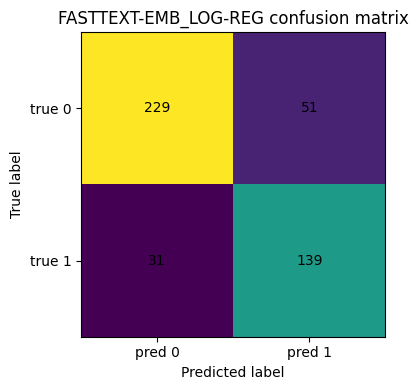

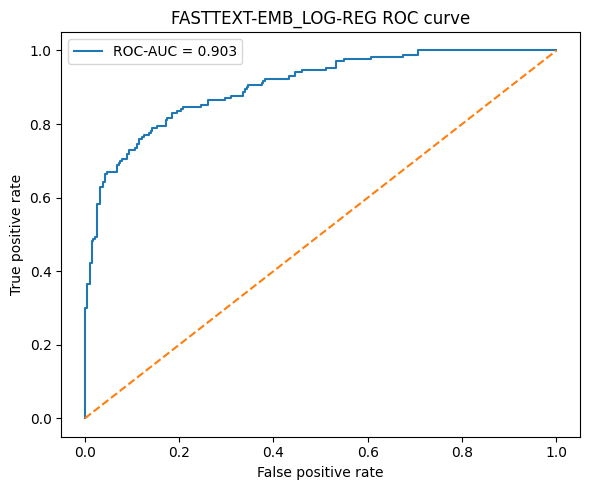

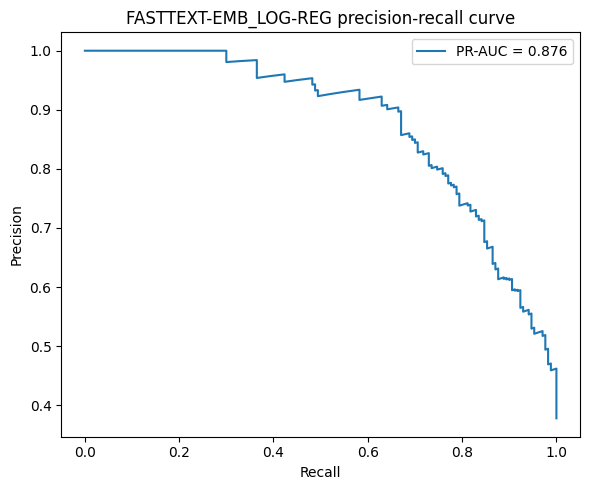

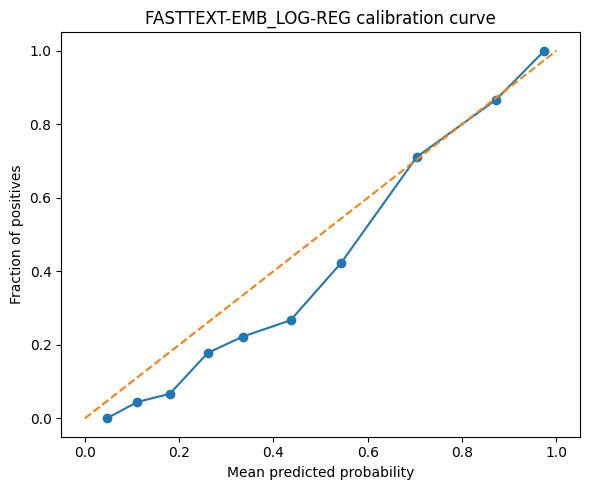

Saved diagnostic plots.


In [15]:
# ============================================================
# 15. Diagnostic plots
# ============================================================

def save_confusion_matrix_plot(cm, path: Path):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["pred 0", "pred 1"])
    ax.set_yticklabels(["true 0", "true 1"])
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(f"{TECHNIQUE_NAME} confusion matrix")

    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            ax.text(c, r, str(cm[r, c]), ha="center", va="center")

    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def save_roc_plot(y_true, y_prob, path: Path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, label=f"ROC-AUC = {safe_roc_auc(y_true, y_prob):.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"{TECHNIQUE_NAME} ROC curve")
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def save_pr_plot(y_true, y_prob, path: Path):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(recall, precision, label=f"PR-AUC = {safe_pr_auc(y_true, y_prob):.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"{TECHNIQUE_NAME} precision-recall curve")
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def save_calibration_plot(y_true, y_prob, path: Path):
    try:
        prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="quantile")
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.plot(prob_pred, prob_true, marker="o")
        ax.plot([0, 1], [0, 1], linestyle="--")
        ax.set_xlabel("Mean predicted probability")
        ax.set_ylabel("Fraction of positives")
        ax.set_title(f"{TECHNIQUE_NAME} calibration curve")
        fig.tight_layout()
        fig.savefig(path, dpi=200, bbox_inches="tight")
        plt.show()
        plt.close(fig)
    except Exception as e:
        print("Could not create calibration plot:", e)

save_confusion_matrix_plot(cm, OUTPUT_DIR / "plots" / "confusion_matrix_test.png")
save_roc_plot(y_test_final, test_prob, OUTPUT_DIR / "plots" / "roc_curve_test.png")
save_pr_plot(y_test_final, test_prob, OUTPUT_DIR / "plots" / "pr_curve_test.png")
save_calibration_plot(y_test_final, test_prob, OUTPUT_DIR / "plots" / "calibration_curve_test.png")

print("Saved diagnostic plots.")


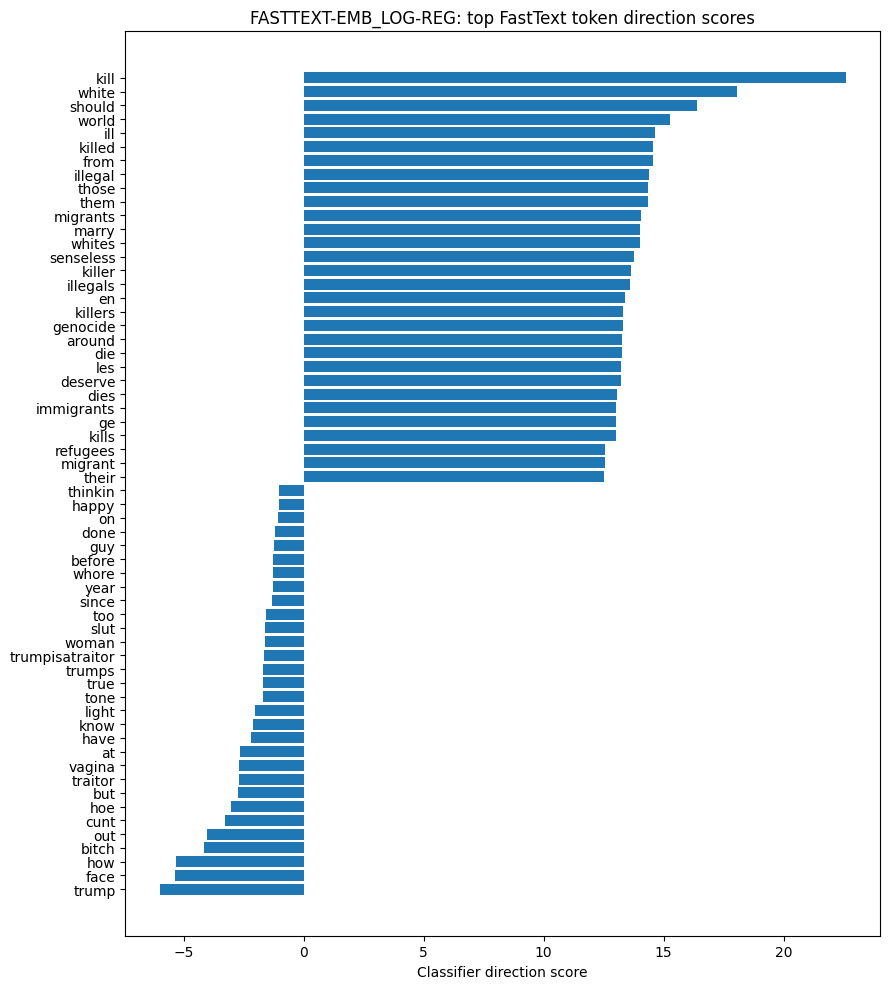

Saved global embedding interpretability files.


,token,vocab_rank,classifier_direction_score,abs_classifier_direction_score
0,kill,18,22.581456,22.581456
1,white,68,18.039886,18.039886
2,should,73,16.385354,16.385354
3,world,82,15.248951,15.248951
4,ill,167,14.629357,14.629357
5,killed,308,14.556422,14.556422
6,from,60,14.539994,14.539994
7,illegal,143,14.391192,14.391192
8,those,125,14.367230,14.367230
9,them,29,14.334117,14.334117


,token,vocab_rank,classifier_direction_score,abs_classifier_direction_score
6332,trump,32,-5.998542,5.998542
6331,face,39,-5.335252,5.335252
6330,how,72,-5.314779,5.314779
6329,bitch,10,-4.155889,4.155889
6328,out,58,-4.016712,4.016712
6327,cunt,100,-3.280652,3.280652
6326,hoe,90,-3.030264,3.030264
6325,but,41,-2.719008,2.719008
6324,traitor,57,-2.708783,2.708783
6323,vagina,83,-2.669114,2.669114


In [16]:
# ============================================================
# 16. Global interpretability: embedding dimensions and token direction scores
# ============================================================

coef_scaled, coef_effective, intercept_effective = get_effective_linear_terms(final_model)

embedding_dimension_df = pd.DataFrame({
    "feature_name": feature_names,
    "coefficient_after_scaling": coef_scaled,
    "coefficient_original_embedding_space": coef_effective,
    "abs_coefficient_original_embedding_space": np.abs(coef_effective),
})

embedding_dimension_df = embedding_dimension_df.sort_values(
    "abs_coefficient_original_embedding_space",
    ascending=False,
).reset_index(drop=True)

embedding_dimension_df.to_csv(
    OUTPUT_DIR / "interpretability" / "global_embedding_dimension_coefficients.csv",
    index=False,
)

# Token direction scores are an approximate global interpretability view:
# a token receives a positive score if its FastText vector points in the classifier's positive-class direction.
max_vocab = CONFIG["explainability"]["max_vocab_tokens_to_score"]
token_rows = []
for rank, token in enumerate(final_fasttext_model.wv.index_to_key[:max_vocab], start=1):
    vec = final_fasttext_model.wv[token]
    score = float(np.dot(coef_effective, vec))
    token_rows.append({
        "token": token,
        "vocab_rank": rank,
        "classifier_direction_score": score,
        "abs_classifier_direction_score": abs(score),
    })

token_direction_scores = pd.DataFrame(token_rows)
token_direction_scores = token_direction_scores.sort_values(
    "classifier_direction_score",
    ascending=False,
).reset_index(drop=True)

top_positive_tokens = token_direction_scores.head(CONFIG["explainability"]["top_n_global"])
top_negative_tokens = token_direction_scores.tail(CONFIG["explainability"]["top_n_global"]).sort_values(
    "classifier_direction_score",
    ascending=True,
)

token_direction_scores.to_csv(
    OUTPUT_DIR / "interpretability" / "token_direction_scores.csv",
    index=False,
)
top_positive_tokens.to_csv(
    OUTPUT_DIR / "interpretability" / "top_positive_tokens.csv",
    index=False,
)
top_negative_tokens.to_csv(
    OUTPUT_DIR / "interpretability" / "top_negative_tokens.csv",
    index=False,
)

# Plot top token direction scores for quick inspection.
plot_n = 30
plot_df = pd.concat([
    top_positive_tokens.head(plot_n).assign(direction="positive"),
    top_negative_tokens.head(plot_n).assign(direction="negative"),
], axis=0)

fig, ax = plt.subplots(figsize=(9, 10))
plot_df = plot_df.sort_values("classifier_direction_score")
ax.barh(plot_df["token"], plot_df["classifier_direction_score"])
ax.set_xlabel("Classifier direction score")
ax.set_title(f"{TECHNIQUE_NAME}: top FastText token direction scores")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "plots" / "top_token_direction_scores.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved global embedding interpretability files.")
display(top_positive_tokens.head(20))
display(top_negative_tokens.head(20))


In [17]:
# ============================================================
# 17. Local interpretability for selected test examples
# ============================================================

def token_contribution_records(tokens, ft_model, pooling, idf_lookup, normalize_embeddings, coef_effective, top_k=15):
    token_items = []
    weighted_sum = np.zeros(ft_model.vector_size, dtype=np.float32)
    total_weight = 0.0

    for token in tokens:
        vec = get_token_vector(ft_model, token)
        if vec is None:
            continue

        if pooling == "idf_weighted_mean":
            weight = float(idf_lookup.get(token, 1.0)) if idf_lookup is not None else 1.0
        elif pooling == "mean":
            weight = 1.0
        else:
            raise ValueError(f"Unknown pooling method: {pooling}")

        token_items.append((token, vec, weight))
        weighted_sum += weight * vec
        total_weight += weight

    if total_weight <= 0 or len(token_items) == 0:
        return {
            "top_positive_features": [],
            "top_negative_features": [],
        }

    pooled = weighted_sum / total_weight
    norm = float(np.linalg.norm(pooled)) if normalize_embeddings else 1.0
    if normalize_embeddings and norm <= 0:
        norm = 1.0

    records = []
    for token, vec, weight in token_items:
        normalized_weight = weight / total_weight
        contribution = float(normalized_weight * np.dot(coef_effective, vec) / norm)
        records.append({
            "feature_name": token,
            "token": token,
            "pooling_weight": float(weight),
            "normalized_pooling_weight": float(normalized_weight),
            "margin_contribution": contribution,
        })

    local_df = pd.DataFrame(records)

    # Combine repeated tokens so repeated language can surface as a stronger local signal.
    local_df = (
        local_df
        .groupby("token", as_index=False)
        .agg(
            feature_name=("feature_name", "first"),
            token_count=("token", "size"),
            pooling_weight=("pooling_weight", "sum"),
            normalized_pooling_weight=("normalized_pooling_weight", "sum"),
            margin_contribution=("margin_contribution", "sum"),
        )
    )

    top_pos = (
        local_df
        .sort_values("margin_contribution", ascending=False)
        .head(top_k)
        .to_dict(orient="records")
    )

    top_neg = (
        local_df
        .sort_values("margin_contribution", ascending=True)
        .head(top_k)
        .to_dict(orient="records")
    )

    return {
        "top_positive_features": top_pos,
        "top_negative_features": top_neg,
    }

def compact_feature_list(records):
    return [
        {
            "feature": r["feature_name"],
            "token_count": int(r["token_count"]),
            "pooling_weight": float(r["pooling_weight"]),
            "normalized_pooling_weight": float(r["normalized_pooling_weight"]),
            "margin_contribution": float(r["margin_contribution"]),
        }
        for r in records
    ]

def select_examples_for_local_explanations(pred_df, max_total=120):
    selected_parts = []

    fp = pred_df[pred_df["error_type"] == "false_positive"].sort_values("y_prob", ascending=False).head(25)
    selected_parts.append(fp.assign(selection_bucket="high_confidence_false_positive"))

    fn = pred_df[pred_df["error_type"] == "false_negative"].sort_values("y_prob", ascending=True).head(25)
    selected_parts.append(fn.assign(selection_bucket="high_confidence_false_negative"))

    pred_df2 = pred_df.copy()
    pred_df2["distance_to_threshold"] = np.abs(pred_df2["y_prob"] - pred_df2["threshold"])

    near_fp = (
        pred_df2[pred_df2["error_type"] == "false_positive"]
        .sort_values("distance_to_threshold", ascending=True)
        .head(25)
    )
    selected_parts.append(near_fp.assign(selection_bucket="near_threshold_false_positive"))

    near_fn = (
        pred_df2[pred_df2["error_type"] == "false_negative"]
        .sort_values("distance_to_threshold", ascending=True)
        .head(25)
    )
    selected_parts.append(near_fn.assign(selection_bucket="near_threshold_false_negative"))

    tp = pred_df[pred_df["error_type"] == "true_positive"].sort_values("y_prob", ascending=False).head(15)
    tn = pred_df[pred_df["error_type"] == "true_negative"].sort_values("y_prob", ascending=True).head(15)
    selected_parts.append(tp.assign(selection_bucket="high_confidence_true_positive"))
    selected_parts.append(tn.assign(selection_bucket="high_confidence_true_negative"))

    selected = pd.concat(selected_parts, axis=0).drop_duplicates(subset=["row_id"])
    selected = selected.head(max_total).reset_index(drop=True)

    return selected

selected_pred_examples = select_examples_for_local_explanations(
    test_predictions,
    max_total=CONFIG["explainability"]["max_local_examples_total"],
)

test_row_position = {rid: i for i, rid in enumerate(test_df[id_col].tolist())}

local_rows = []
for _, pred_row in selected_pred_examples.iterrows():
    rid = pred_row["row_id"]
    pos = test_row_position[rid]

    explanation = token_contribution_records(
        tokens=final_tokenized_test[pos],
        ft_model=final_fasttext_model,
        pooling=embedding_cfg["pooling"],
        idf_lookup=final_idf_lookup,
        normalize_embeddings=bool(embedding_cfg["normalize_embeddings"]),
        coef_effective=coef_effective,
        top_k=CONFIG["explainability"]["top_k_local_features"],
    )

    base = {
        "run_id": RUN_ID,
        "technique": TECHNIQUE_NAME,
        "row_id": rid,
        "selection_bucket": pred_row["selection_bucket"],
        "y_true": int(pred_row["y_true"]),
        "y_pred": int(pred_row["y_pred"]),
        "y_prob": float(pred_row["y_prob"]),
        "y_margin": float(pred_row["y_margin"]) if "y_margin" in pred_row else None,
        "threshold": float(pred_row["threshold"]),
        "error_type": pred_row["error_type"],
        "text_hash": pred_row["text_hash"],
        "top_positive_features_json": json.dumps(compact_feature_list(explanation["top_positive_features"])),
        "top_negative_features_json": json.dumps(compact_feature_list(explanation["top_negative_features"])),
    }

    if CONFIG["explainability"]["include_text_preview"]:
        text_value = test_df.iloc[pos][text_col]
        base["text_preview"] = text_value[:CONFIG["explainability"]["text_preview_chars"]]

    local_rows.append(base)

local_explanations = pd.DataFrame(local_rows)
local_explanations.to_csv(
    OUTPUT_DIR / "interpretability" / "local_explanations.csv",
    index=False,
)

print("Saved local explanations:", OUTPUT_DIR / "interpretability" / "local_explanations.csv")
display(local_explanations.head())


Saved local explanations: /kaggle/working/experiments/FASTTEXT-EMB_LOG-REG/interpretability/local_explanations.csv


,run_id,technique,row_id,selection_bucket,y_true,y_pred,y_prob,y_margin,threshold,error_type,text_hash,top_positive_features_json,top_negative_features_json
0,FASTTEXT-EMB_LOG-REG_20260708_174434,FASTTEXT-EMB_LOG-REG,ex_000593,high_confidence_false_positive,0,1,0.928465,2.563345,0.47,false_positive,54d8c0356787a8c7,"[{""feature"": ""genocide"", ""token_count"": 1, ""pooling_weight"": 1.0, ""normalized_pooling_weight"": 0.25, ""margin_contrib...","[{""feature"": ""okay"", ""token_count"": 1, ""pooling_weight"": 1.0, ""normalized_pooling_weight"": 0.25, ""margin_contributio..."
1,FASTTEXT-EMB_LOG-REG_20260708_174434,FASTTEXT-EMB_LOG-REG,ex_000120,high_confidence_false_positive,0,1,0.885291,2.043516,0.47,false_positive,733708428c48bdd0,"[{""feature"": ""genocide"", ""token_count"": 1, ""pooling_weight"": 1.0, ""normalized_pooling_weight"": 0.058823529411764705,...","[{""feature"": ""in"", ""token_count"": 1, ""pooling_weight"": 1.0, ""normalized_pooling_weight"": 0.058823529411764705, ""marg..."
2,FASTTEXT-EMB_LOG-REG_20260708_174434,FASTTEXT-EMB_LOG-REG,ex_000874,high_confidence_false_positive,0,1,0.876919,1.963576,0.47,false_positive,c64011dfec0bfc74,"[{""feature"": ""are"", ""token_count"": 2, ""pooling_weight"": 2.0, ""normalized_pooling_weight"": 0.16666666666666666, ""marg...","[{""feature"": ""why"", ""token_count"": 1, ""pooling_weight"": 1.0, ""normalized_pooling_weight"": 0.08333333333333333, ""marg..."
3,FASTTEXT-EMB_LOG-REG_20260708_174434,FASTTEXT-EMB_LOG-REG,ex_002371,high_confidence_false_positive,0,1,0.850976,1.742276,0.47,false_positive,3006caea5f7f3fca,"[{""feature"": ""illegal"", ""token_count"": 1, ""pooling_weight"": 1.0, ""normalized_pooling_weight"": 0.06666666666666667, ""...","[{""feature"": ""to"", ""token_count"": 2, ""pooling_weight"": 2.0, ""normalized_pooling_weight"": 0.13333333333333333, ""margi..."
4,FASTTEXT-EMB_LOG-REG_20260708_174434,FASTTEXT-EMB_LOG-REG,ex_000117,high_confidence_false_positive,0,1,0.804285,1.413296,0.47,false_positive,b9cd63a2e64e0227,"[{""feature"": ""immigrant"", ""token_count"": 1, ""pooling_weight"": 1.0, ""normalized_pooling_weight"": 0.08333333333333333,...","[{""feature"": ""igor"", ""token_count"": 1, ""pooling_weight"": 1.0, ""normalized_pooling_weight"": 0.08333333333333333, ""mar..."


In [18]:
# ============================================================
# 18. Error-analysis outputs
# ============================================================

error_df = test_predictions.copy()
error_df["abs_distance_to_threshold"] = np.abs(error_df["y_prob"] - error_df["threshold"])

def confidence_bucket(row):
    if row["abs_distance_to_threshold"] <= CONFIG["error_analysis"]["near_threshold_margin"]:
        return "near_threshold"
    if row["y_prob"] >= 0.90 or row["y_prob"] <= 0.10:
        return "high_confidence"
    return "moderate_confidence"

error_df["confidence_bucket"] = error_df.apply(confidence_bucket, axis=1)
error_df["manual_error_category"] = ""
error_df["manual_notes"] = ""

if not local_explanations.empty:
    feature_cols = local_explanations[
        ["row_id", "top_positive_features_json", "top_negative_features_json"]
    ].drop_duplicates("row_id")
    error_df = error_df.merge(feature_cols, on="row_id", how="left")

if CONFIG["error_analysis"]["include_text_preview"]:
    text_lookup = test_df[[id_col, text_col]].copy()
    text_lookup["text_preview"] = text_lookup[text_col].str.slice(0, CONFIG["error_analysis"]["text_preview_chars"])
    error_df = error_df.merge(text_lookup[[id_col, "text_preview"]], left_on="row_id", right_on=id_col, how="left")
    if id_col in error_df.columns and id_col != "row_id":
        error_df = error_df.drop(columns=[id_col])

error_df.to_csv(OUTPUT_DIR / "error_analysis" / "error_analysis_test.csv", index=False)

review_parts = []
n = CONFIG["error_analysis"]["examples_per_bucket"]

review_parts.append(
    error_df[error_df["error_type"] == "false_positive"]
    .sort_values("y_prob", ascending=False)
    .head(n)
    .assign(review_bucket="highest_confidence_false_positive")
)

review_parts.append(
    error_df[error_df["error_type"] == "false_negative"]
    .sort_values("y_prob", ascending=True)
    .head(n)
    .assign(review_bucket="highest_confidence_false_negative")
)

review_parts.append(
    error_df[error_df["error_type"] == "false_positive"]
    .sort_values("abs_distance_to_threshold", ascending=True)
    .head(n)
    .assign(review_bucket="near_threshold_false_positive")
)

review_parts.append(
    error_df[error_df["error_type"] == "false_negative"]
    .sort_values("abs_distance_to_threshold", ascending=True)
    .head(n)
    .assign(review_bucket="near_threshold_false_negative")
)

selected_review_examples = (
    pd.concat(review_parts, axis=0)
    .drop_duplicates(subset=["row_id"])
    .reset_index(drop=True)
)

selected_review_examples.to_csv(
    OUTPUT_DIR / "error_analysis" / "selected_examples_for_review.csv",
    index=False,
)

print("Saved error analysis files:")
print("-", OUTPUT_DIR / "error_analysis" / "error_analysis_test.csv")
print("-", OUTPUT_DIR / "error_analysis" / "selected_examples_for_review.csv")

display(error_df["error_type"].value_counts().to_frame("count"))
display(error_df.groupby(["error_type", "confidence_bucket"]).size().reset_index(name="count"))


Saved error analysis files:
- /kaggle/working/experiments/FASTTEXT-EMB_LOG-REG/error_analysis/error_analysis_test.csv
- /kaggle/working/experiments/FASTTEXT-EMB_LOG-REG/error_analysis/selected_examples_for_review.csv


,count
error_type,
true_negative,229
true_positive,139
false_positive,51
false_negative,31


,error_type,confidence_bucket,count
0,false_negative,moderate_confidence,26
1,false_negative,near_threshold,5
2,false_positive,high_confidence,1
3,false_positive,moderate_confidence,34
4,false_positive,near_threshold,16
5,true_negative,high_confidence,59
6,true_negative,moderate_confidence,155
7,true_negative,near_threshold,15
8,true_positive,high_confidence,57
9,true_positive,moderate_confidence,74


In [19]:
# ============================================================
# 19. Save experiment metadata and output README
# ============================================================

metadata = {
    "run_id": RUN_ID,
    "technique": TECHNIQUE_NAME,
    "created_at_utc": dt.datetime.utcnow().replace(microsecond=0).isoformat() + "Z",
    "project_name": CONFIG["project_name"],
    "dataset_version": CONFIG["dataset_version"],
    "split_version": CONFIG["split_version"],
    "random_seed": CONFIG["random_seed"],
    "processed_dataset_path": str(processed_dataset_path),
    "processed_dataset_sha256_16": sha256_file(processed_dataset_path),
    "split_assignments_path": str(split_assignments_path),
    "split_assignments_sha256_16": sha256_file(split_assignments_path),
    "dataset_manifest": dataset_manifest,
    "software_environment": {
        "python_version": platform.python_version(),
        "platform": platform.platform(),
        "numpy_version": np.__version__,
        "pandas_version": pd.__version__,
        "gensim_version": gensim.__version__,
    },
    "sklearn_version": __import__("sklearn").__version__,
    "model_selection": {
        "ablation_split": "validation",
        "primary_selection_metric": "positive_f1",
        "test_set_used_for_selection": False,
    },
    "final_evaluation": {
        "test_split_used_once_after_selection": True,
        "threshold_selected_on": "validation",
    },
    "probability_modeling": {
        "method": "native LogisticRegression predict_proba",
        "fit_on": "train split only",
    },
    "outputs": {
        "config": "config.json",
        "best_config": "best_config.json",
        "ablation_results": "ablation/ablation_results.csv",
        "metrics_validation": "metrics_validation.json",
        "metrics_test": "metrics_test.json",
        "predictions_validation": "predictions_validation.csv",
        "predictions_test": "predictions_test.csv",
        "model_artifacts": "model_artifacts/",
        "plots": "plots/",
        "interpretability": "interpretability/",
        "error_analysis": "error_analysis/",
    },
}

save_json(metadata, OUTPUT_DIR / "metadata.json")

readme_text = f"""# {TECHNIQUE_NAME} outputs

This folder contains the standardized outputs for the `{TECHNIQUE_NAME}` experiment.

## Research protocol

- Dataset: `{CONFIG['dataset_version']}`
- Split version: `{CONFIG['split_version']}`
- Model selection: validation-only
- Primary selection metric: validation positive-class F1
- Threshold selection: validation-only
- Final test evaluation: held-out test split only

## Model details

This model trains FastText word embeddings on the train split only, pools token vectors into document-level embeddings, and trains a regularized logistic-regression classifier. FastText uses subword character n-grams, so it can represent rare, misspelled, slang, hashtag, and mildly obfuscated social-media terms more flexibly than ordinary Word2Vec-style embeddings. The classifier uses `StandardScaler + LogisticRegression`, so probabilities come from logistic regression directly rather than a separate calibration step.

## Interpretability note

Embedding dimensions are not directly human-readable like TF-IDF tokens. This notebook therefore saves two complementary interpretability views:

- `global_embedding_dimension_coefficients.csv`: classifier coefficients over embedding dimensions
- `token_direction_scores.csv`: approximate global token scores from each token vector's dot product with the classifier direction
- `local_explanations.csv`: approximate token-level margin contributions for selected test examples

## Key files

- `metrics_test.json`: final held-out test metrics
- `predictions_test.csv`: standardized row-level test predictions
- `ablation/ablation_results.csv`: validation-only tuning results
- `best_config.json`: selected model configuration
- `model_artifacts/`: trained classifier, FastText model, IDF lookup, feature names, threshold
- `interpretability/`: global and local embedding/token contribution outputs
- `error_analysis/`: tables for false-positive/false-negative review
"""

with open(OUTPUT_DIR / "README_outputs.md", "w") as f:
    f.write(readme_text)

print("Saved metadata and output README.")
print("Output directory:", OUTPUT_DIR)


Saved metadata and output README.
Output directory: /kaggle/working/experiments/FASTTEXT-EMB_LOG-REG


/tmp/ipykernel_23/1084457209.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at_utc": dt.datetime.utcnow().replace(microsecond=0).isoformat() + "Z",


In [20]:
# ============================================================
# 20. Zip outputs for download / Google Drive storage
# ============================================================

zip_base = Path("/kaggle/working") / f"{TECHNIQUE_NAME}_outputs"
zip_path = shutil.make_archive(
    base_name=str(zip_base),
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("Created zip file:")
print(zip_path)

print("\nUpload this zip to Google Drive:")
print(f"Extremism-Classification-Research/01_model_outputs/{TECHNIQUE_NAME}/")


Created zip file:
/kaggle/working/FASTTEXT-EMB_LOG-REG_outputs.zip

Upload this zip to Google Drive:
Extremism-Classification-Research/01_model_outputs/FASTTEXT-EMB_LOG-REG/
